# 05 — Full System Evaluation
Runs the chatbot pipeline on the 10-query test set and computes BLEU, ROUGE-L, and visualisations for the report.

In [2]:
import sys, os

# Fix working directory — must point to project root, not notebooks/
os.chdir(os.path.abspath(".."))
sys.path.insert(0, os.getcwd())

# Force offline mode — prevents any HuggingFace re-downloads
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

print("Working directory:", os.getcwd())
print("Model exists:", os.path.exists("models/intent_classifier/config.json"))
print("FAISS index exists:", os.path.exists("models/faiss_index.bin"))
print("Test queries exist:", os.path.exists("evaluation/test_queries.csv"))

Working directory: E:\Uni\Semester 7\EC7203- Advanced Artificial Inteligence\AI-chatbot-project
Model exists: True
FAISS index exists: True
Test queries exist: True


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from src.chatbot_pipeline import chat

nltk.download("punkt", quiet=True)
print("Imports successful")

Imports successful


In [4]:
test_set = pd.read_csv("evaluation/test_queries.csv")
print(f"Loaded {len(test_set)} test queries")
test_set.head()

Loaded 10 test queries


,query,reference
0,How do I reset my online banking password?,"To reset your password, go to the login page a..."
1,How do I dispute a charge on my bill?,"If you notice an incorrect charge, go to Billi..."
2,My card was charged twice for the same transac...,Duplicate charges are usually automatically re...
3,I want to close my account.,"To request account closure, please download th..."
4,What payment methods are accepted?,"We accept debit card, credit card, bank transf..."


In [5]:
scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
chencherry = SmoothingFunction()

results = []
for _, row in test_set.iterrows():
    response, intent, sentiment, escalated = chat(row["query"], [])
    bleu = sentence_bleu(
        [row["reference"].split()],
        response.split(),
        smoothing_function=chencherry.method1
    )
    rouge_l = scorer.score(row["reference"], response)["rougeL"].fmeasure
    results.append({
        "query": row["query"],
        "reference": row["reference"],
        "response": response,
        "bleu": round(bleu, 4),
        "rouge_l": round(rouge_l, 4),
        "intent": intent,
        "sentiment": sentiment,
        "escalated": escalated
    })
    print(f"Done: {row['query'][:55]}...")

results_df = pd.DataFrame(results)
results_df.to_csv("evaluation/results.csv", index=False)
print("\nSaved to evaluation/results.csv")
results_df

Done: How do I reset my online banking password?...
Done: How do I dispute a charge on my bill?...
Done: My card was charged twice for the same transaction....
Done: I want to close my account....
Done: What payment methods are accepted?...
Done: My card was stolen, what should I do?...
Done: How do I report a suspicious transaction?...
Done: Why is my internet connection not working?...
Done: How do I cancel a subscription or add-on service?...
Done: How do I update my billing address?...

Saved to evaluation/results.csv


,query,reference,response,bleu,rouge_l,intent,sentiment,escalated
0,How do I reset my online banking password?,"To reset your password, go to the login page a...","To reset your online banking password, go to t...",0.9284,0.9800,passcode_forgotten,Negative,False
1,How do I dispute a charge on my bill?,"If you notice an incorrect charge, go to Billi...",You can dispute an incorrect charge by going t...,0.3154,0.6737,direct_debit_payment_not_recognised,Negative,False
2,My card was charged twice for the same transac...,Duplicate charges are usually automatically re...,"To dispute a charge on your bill, go to Billin...",0.0585,0.1579,transaction_charged_twice,Negative,False
3,I want to close my account.,"To request account closure, please download th...","To close your account, ensure it is zeroed out...",0.0067,0.1765,terminate_account,Negative,False
4,What payment methods are accepted?,"We accept debit card, credit card, bank transf...","You can pay with bank transfer, debit card, cr...",0.0754,0.2727,supported_cards_and_currencies,Negative,False
5,"My card was stolen, what should I do?","If your card is lost or stolen, immediately fr...",You should freeze your card immediately under ...,0.0172,0.2979,lost_or_stolen_card,Negative,False
6,How do I report a suspicious transaction?,"To report a suspicious transaction, go to Secu...",You should contact our 24/7 fraud hotline to r...,0.0085,0.2041,cancel_transfer,Negative,False
7,Why is my internet connection not working?,First restart your router by unplugging it for...,Online banking supports the latest versions of...,0.0038,0.0455,lost_or_stolen_phone,Negative,False
8,How do I cancel a subscription or add-on service?,"To cancel a subscription or add-on, go to Subs...","To cancel a subscription or add-on service, go...",0.2463,0.6494,terminate_account,Negative,False
9,How do I update my billing address?,You can update your billing address under Sett...,To update your billing address under Account >...,0.2598,0.4878,edit_personal_details,Negative,False


In [6]:
print(f"Average BLEU:    {results_df['bleu'].mean():.4f}")
print(f"Average ROUGE-L: {results_df['rouge_l'].mean():.4f}")
print(f"Escalation rate: {results_df['escalated'].mean():.2%}")

Average BLEU:    0.1920
Average ROUGE-L: 0.3946
Escalation rate: 0.00%


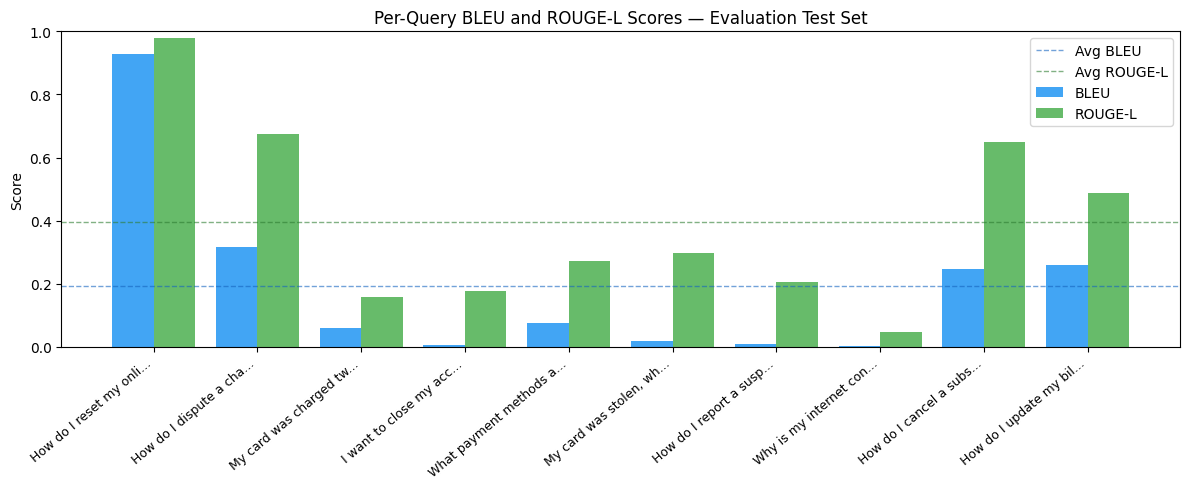

Saved: notebooks/per_query_scores.png


In [7]:
# Figure 4 — Per-query BLEU and ROUGE-L side-by-side bar chart (for report)
short_labels = [q[:22]+"..." for q in results_df["query"]]
x = range(len(results_df))

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar([i - 0.2 for i in x], results_df["bleu"],   width=0.4, label="BLEU",   color="#2196F3", alpha=0.85)
bars2 = ax.bar([i + 0.2 for i in x], results_df["rouge_l"], width=0.4, label="ROUGE-L", color="#4CAF50", alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(short_labels, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("Score")
ax.set_title("Per-Query BLEU and ROUGE-L Scores — Evaluation Test Set")
ax.legend()
ax.set_ylim(0, 1.0)
ax.axhline(results_df["bleu"].mean(),   color="#1565C0", linestyle="--", linewidth=1, alpha=0.6, label="Avg BLEU")
ax.axhline(results_df["rouge_l"].mean(), color="#2E7D32", linestyle="--", linewidth=1, alpha=0.6, label="Avg ROUGE-L")
ax.legend()
plt.tight_layout()
plt.savefig("notebooks/per_query_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: notebooks/per_query_scores.png")

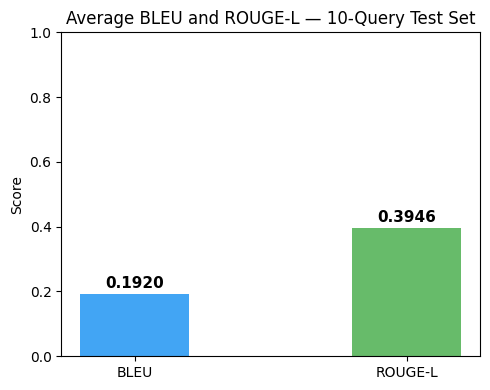

Saved: notebooks/avg_metrics.png


In [8]:
# Average metric summary bar chart
fig, ax = plt.subplots(figsize=(5, 4))
metrics = {"BLEU": results_df["bleu"].mean(), "ROUGE-L": results_df["rouge_l"].mean()}
colors = ["#2196F3", "#4CAF50"]
bars = ax.bar(metrics.keys(), metrics.values(), color=colors, alpha=0.85, width=0.4)
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Score")
ax.set_title("Average BLEU and ROUGE-L — 10-Query Test Set")
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig("notebooks/avg_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: notebooks/avg_metrics.png")

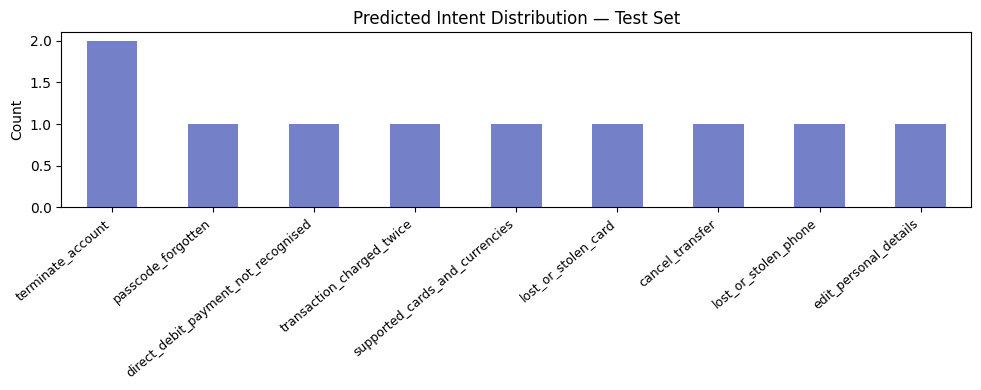

In [9]:
# Intent distribution chart
fig, ax = plt.subplots(figsize=(10, 4))
results_df["intent"].value_counts().plot(kind="bar", ax=ax, color="#5C6BC0", alpha=0.85)
ax.set_title("Predicted Intent Distribution — Test Set")
ax.set_ylabel("Count")
ax.set_xlabel("")
plt.xticks(rotation=40, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig("notebooks/intent_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

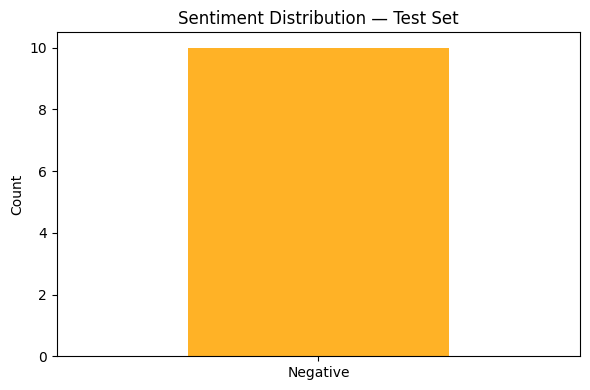

In [10]:
# Sentiment distribution chart — safe color mapping (handles any number of unique values)
sentiment_colors = {"Positive": "green", "Neutral": "gray", "Negative": "orange", "Crisis": "red"}
sentiment_counts = results_df["sentiment"].value_counts()
colors = [sentiment_colors.get(s, "steelblue") for s in sentiment_counts.index]

fig, ax = plt.subplots(figsize=(6, 4))
sentiment_counts.plot(kind="bar", ax=ax, color=colors, alpha=0.85)
ax.set_title("Sentiment Distribution — Test Set")
ax.set_ylabel("Count")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("notebooks/sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary
Charts saved to `notebooks/` folder:
- `per_query_scores.png` → use as **Figure 4** in report
- `avg_metrics.png` → use as supplementary chart
- `intent_distribution.png` → intent analysis evidence
- `sentiment_distribution.png` → sentiment analysis evidence

Results saved to `evaluation/results.csv` — use for **Table 6** in report.